In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Loading the data


In [5]:
#loading the mnist data
dataset = MNIST(
    root="./data",
    train=True,
    transform=transforms.ToTensor(),
    download=True
)

#dataloader
loader = DataLoader(dataset, batch_size=512, shuffle=True)
images, labels = next(iter(loader))

print(images.shape)
print(labels.shape)



torch.Size([512, 1, 28, 28])
torch.Size([512])


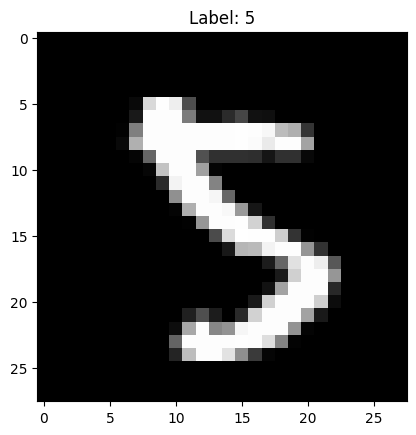

In [6]:
#testing laoded MNIST data
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.show()


Definfing model

In [7]:
class AutoEncoder(nn.Module):
  def __init__(self,input_dim,latent_dim):
    super().__init__()
    self.encoder1 = nn.Linear(in_features=input_dim,out_features=latent_dim) #sequential encoder 1
    self.encoder2 = nn.Linear(in_features=latent_dim,out_features=32) #sequential encoder 2

    self.decoder1 = nn.Linear(in_features=32,out_features=latent_dim) #sequential decoder 1
    self.decoder2 = nn.Linear(in_features=latent_dim,out_features=input_dim) #sequential decoder 2

  def forward(self,x):
    latent = self.run_encoder(x)#latent definitoin
    x_recon = self.run_decoder(latent)#reonstructed data
    return x_recon

  #encoder definition , X-->encoder1-->encoder2-->Latent
  def run_encoder(self,x):
    output = F.relu(self.encoder1(x))
    latent = F.relu(self.encoder2(output))
    return latent

  def run_decoder(self,latent):
    output = F.relu(self.decoder1(latent))
    x_recon = torch.sigmoid(self.decoder2(output))#sigmoid bcs greyscale reconstruction
    return x_recon


TRAINING OUR DATA!!

In [8]:
model = AutoEncoder(input_dim=784, latent_dim=124)  # 784 = 28x28 MNIST
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss() #binary loss for greyscale image reonstruction

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

epochs = 20
for epoch in range(epochs):
    total_loss = 0
    for images, _ in loader:
        images = images.view(-1, 784).to(device)
        recon = model(images)
        loss = criterion(recon, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.4f}")

Epoch 1/20 | Loss: 0.3161
Epoch 2/20 | Loss: 0.1949
Epoch 3/20 | Loss: 0.1591
Epoch 4/20 | Loss: 0.1414
Epoch 5/20 | Loss: 0.1305
Epoch 6/20 | Loss: 0.1232
Epoch 7/20 | Loss: 0.1171
Epoch 8/20 | Loss: 0.1124
Epoch 9/20 | Loss: 0.1091
Epoch 10/20 | Loss: 0.1066
Epoch 11/20 | Loss: 0.1045
Epoch 12/20 | Loss: 0.1029
Epoch 13/20 | Loss: 0.1015
Epoch 14/20 | Loss: 0.1004
Epoch 15/20 | Loss: 0.0994
Epoch 16/20 | Loss: 0.0986
Epoch 17/20 | Loss: 0.0978
Epoch 18/20 | Loss: 0.0971
Epoch 19/20 | Loss: 0.0964
Epoch 20/20 | Loss: 0.0957


PLotting it 

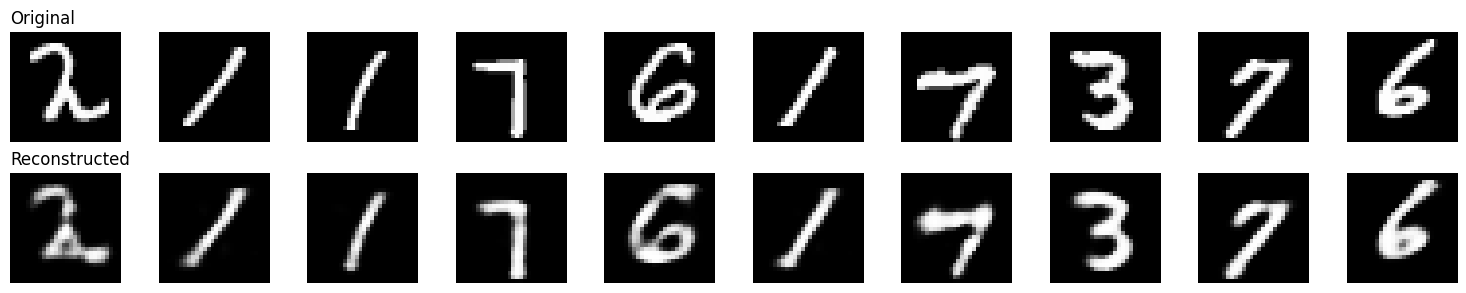

In [10]:
model.eval()
with torch.no_grad():
    images, _ = next(iter(loader))
    images_flat = images.view(-1, 784).to(device)
    recon = model(images_flat)

    # Reshape back to 28x28 for display
    images_grid = images.view(-1, 28, 28)
    recon_grid = recon.view(-1, 28, 28)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(images_grid[i].cpu(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_grid[i].cpu(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title('Original', loc='left')
axes[1, 0].set_title('Reconstructed', loc='left')
plt.tight_layout()
plt.show()

MOMENT OF TRUTH

In a standard Autoencoder, the latent space is learned deterministically as a set of isolated points. Because the model only learns to map specific training data to specific coordinates, it leaves 'gaps' of empty space in between. When we use torch.randn to sample a random vector, we are essentially picking a coordinate that has no reference to real data, so the decoder produces unstructured garbage.

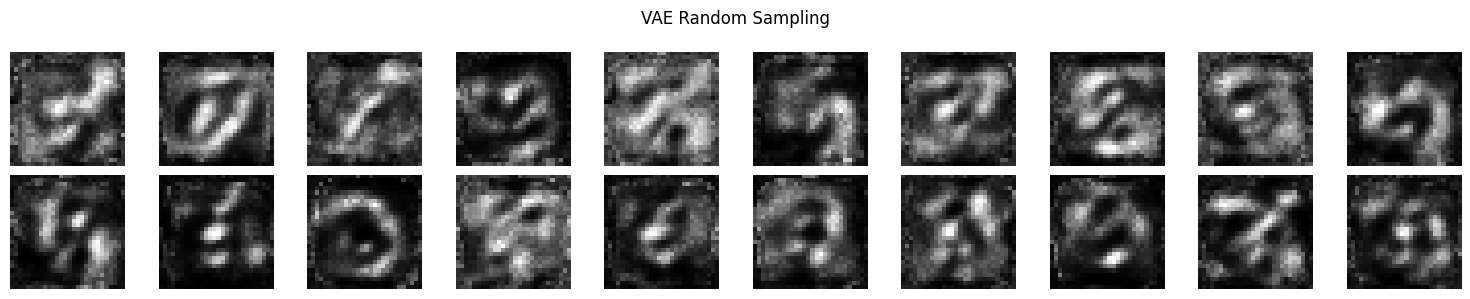

In [ ]:
model.eval()
with torch.no_grad():
    latent_dim = 32  
    z = torch.randn(20, latent_dim).to(device)
    generated = model.run_decoder(z) if hasattr(model, "run_decoder") else model.decoder(z)

    generated = generated.view(-1, 28, 28)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    axes[i//10, i%10].imshow(generated[i].cpu(), cmap="gray")
    axes[i//10, i%10].axis("off")

plt.suptitle("VAE Random Sampling")
plt.tight_layout()
plt.show()